# Customer Churn Prediction

Trying to predict which telecom customers are going to cancel their subscription, using the Telco churn dataset. Main thing I focused on: not letting test data leak into training, and dealing with the fact that way more people stay than leave (so accuracy alone is a bad metric here).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### Loading and cleaning the data

TotalCharges has some blank strings instead of actual numbers (probably new customers who haven't been billed yet), so I convert it to numeric and drop those rows since it's only like 11 of them.

In [2]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df.shape)
print(df['Churn'].value_counts(normalize=True))

(7032, 20)
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


About 73% stay and 27% churn, so it's imbalanced. Keeping that in mind for later.

### Encoding + train/test split

One-hot encoding the categorical columns (dropping the first category each time so we don't end up with duplicate info). Then splitting into train/test BEFORE scaling anything, otherwise info from the test set leaks into training and the scores end up looking better than they really are.

In [3]:
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


### Scaling + feature selection

Fitting the scaler only on training data. Then using a Random Forest to figure out which features actually matter and dropping the bottom half, since a lot of the one-hot columns are probably not doing much.

In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

selector = SelectFromModel(rf_selector, threshold='median', prefit=True)
X_train_opt = selector.transform(X_train)
X_test_opt = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support(indices=True)]
print(f"Went from {X_train.shape[1]} features down to {X_train_opt.shape[1]}")

Went from 30 features down to 15


### Training the model

Using Logistic Regression with `class_weight='balanced'` so it doesn't just learn to predict "stays" for everyone (which would give ~73% accuracy but be useless). This makes it penalize missed churners more.

              precision    recall  f1-score   support

           0       0.90      0.69      0.78      1033
           1       0.48      0.80      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

ROC AUC: 0.8321060097012491


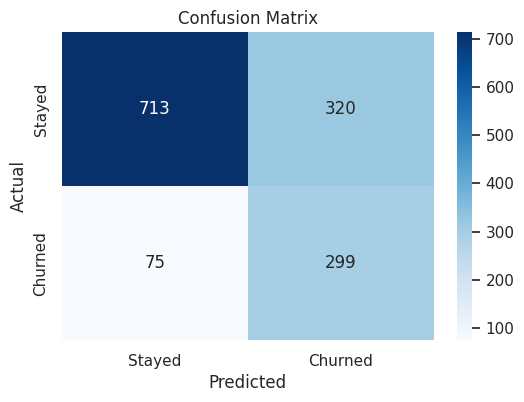

In [5]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_opt, y_train)

y_pred = log_reg.predict(X_test_opt)
y_prob = log_reg.predict_proba(X_test_opt)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Recall for churners (class 1) is 0.80, which is what I actually care about here - catching most of the people who are going to leave, even if it means flagging some people who were going to stay anyway.

### What's actually driving churn

Pulling the coefficients out of the model to see which features push people toward churning (positive) vs staying (negative).

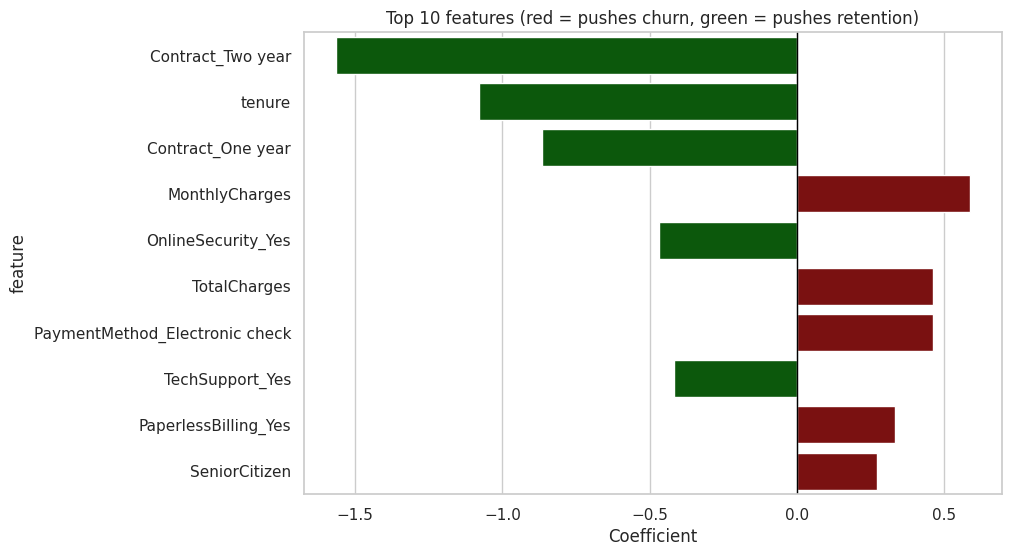

In [6]:
coefs = pd.DataFrame({
    'feature': selected_features,
    'coef': log_reg.coef_[0]
})
coefs['abs_coef'] = coefs['coef'].abs()
top10 = coefs.sort_values('abs_coef', ascending=False).head(10)

colors = ['darkred' if c > 0 else 'darkgreen' for c in top10['coef']]

plt.figure(figsize=(9,6))
sns.barplot(x='coef', y='feature', data=top10, hue='feature', palette=colors, legend=False)
plt.axvline(0, color='black', linewidth=1)
plt.title('Top 10 features (red = pushes churn, green = pushes retention)')
plt.xlabel('Coefficient')
plt.show()

### Checking the score isn't just luck

Just to make sure that 0.83 ROC AUC wasn't a fluke from the specific train/test split, running 5-fold cross validation on the training set.

In [7]:
cv_scores = cross_val_score(log_reg, X_train_opt, y_train, cv=5, scoring='roc_auc')
print(cv_scores)
print("avg:", cv_scores.mean(), "std:", cv_scores.std())

[0.83196207 0.87121316 0.83775215 0.80914995 0.8555435 ]
avg: 0.8411241669163555 std: 0.021123114756221157


Pretty consistent across folds, so the score seems real and not just a lucky split.

### Trying a few different C values

`C` controls how much regularization the model uses. Just looping through a few values manually to see if the default was already close to the best one.

In [8]:
for c in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=c, class_weight='balanced', random_state=42)
    scores = cross_val_score(model, X_train_opt, y_train, cv=5, scoring='roc_auc')
    print(f"C={c}: {scores.mean():.3f}")

C=0.01: 0.838
C=0.1: 0.841


C=1: 0.841


C=10: 0.841
C=100: 0.841


C=100 gave the best average, so using that for the final model instead of the default (C=1).

In [9]:
log_reg_final = LogisticRegression(C=100, class_weight='balanced', random_state=42)
log_reg_final.fit(X_train_opt, y_train)

y_prob_final = log_reg_final.predict_proba(X_test_opt)[:, 1]
print("ROC AUC with tuned C:", roc_auc_score(y_test, y_prob_final))

ROC AUC with tuned C: 0.8320387118149204


### Comparing against Random Forest

I already used Random Forest to pick features, but wanted to check if it would actually do better as the final model too, instead of Logistic Regression.

In [10]:
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_opt, y_train)
rf_prob = rf_model.predict_proba(X_test_opt)[:, 1]

print("Logistic Regression AUC:", roc_auc_score(y_test, y_prob_final))
print("Random Forest AUC:", roc_auc_score(y_test, rf_prob))

Logistic Regression AUC: 0.8320387118149204
Random Forest AUC: 0.8092182573988851


Logistic Regression came out ahead, and it's easier to explain to someone why it made a prediction, so sticking with that as the final model.

### Trying a different cutoff

By default, if the model thinks there's more than 50% chance of churn, it predicts "churn". But since missing a churner is worse than wrongly flagging someone, tried lowering that cutoff a bit to catch more of them.

In [11]:
for t in [0.3, 0.4, 0.5, 0.6]:
    preds = (y_prob_final >= t).astype(int)
    report = classification_report(y_test, preds, output_dict=True)
    print(f"threshold={t}  recall={report['1']['recall']:.2f}  precision={report['1']['precision']:.2f}")

threshold=0.3  recall=0.92  precision=0.41
threshold=0.4  recall=0.88  precision=0.44
threshold=0.5  recall=0.80  precision=0.48
threshold=0.6  recall=0.71  precision=0.55


0.5 already gives around 80% recall on churners, so didn't really need to move it much. Good to know it wasn't hiding a big improvement somewhere else though.

### Saving the model

So it can be loaded later without retraining everything from scratch.

In [12]:
joblib.dump(log_reg_final, 'churn_model.pkl')
joblib.dump(scaler, 'churn_scaler.pkl')
joblib.dump(selector, 'churn_feature_selector.pkl')
print("saved")

saved
